In [1]:
!nvidia-smi

Sat Aug  8 12:17:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 45 (delta 5), reused 3 (delta 3), pack-reused 37 (from 1)
Receiving objects: 100% (45/45), 45.99 KiB | 2.87 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [3]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [4]:
!pip install -q torchattacks torchsummary


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
google-adk 2.4.0 requires requests<3,>=2.32.4, but you have requests 2.25.1 which is incompatible.
datasets 4.0.0 requires requests>=2.32.2, but you have request

In [5]:
# ======================================
# GOOGLE DRIVE CHECKPOINT SETUP
# ======================================

from google.colab import drive
import os
import torch

# Mount Google Drive
drive.mount('/content/drive')


# Folder lưu checkpoint trên Drive
checkpoint_dir = "/content/drive/MyDrive/LNL_Checkpoint"

os.makedirs(
    checkpoint_dir,
    exist_ok=True
)


print("Checkpoint path:")
print(checkpoint_dir)

Mounted at /content/drive
Checkpoint path:
/content/drive/MyDrive/LNL_Checkpoint


In [6]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
# ===============================
# CREATE CHECKPOINT FOLDER
# ===============================

import os

In [7]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
# ===============================
# CREATE CHECKPOINT FOLDER
# ===============================

import os

checkpoint_dir = "./checkpoint"

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

print("Checkpoint folder ready!")

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

# Tang toc GPU: cho phep cuDNN tu chon thuat toan toi uu nhat cho kich thuoc input co dinh
torch.backends.cudnn.benchmark = True


Checkpoint folder ready!


In [8]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [9]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  11.1M      0  0:00:23  0:00:23 --:--:-- 15.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  12.6M      0  0:00:06  0:00:06 --:--:-- 16.3M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0    98k      0 --:--:-- --:--:-- --:--:--   98k


In [10]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/



Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [11]:
import shutil

In [12]:
import os
import shutil

# The exact path based on the current file tree
base_search_dir = '/content/Locality-iN-Locality/data' # Corrected path
print(f"Searching for GTSRB data in: {base_search_dir}")

csv_path = None
train_src = None
test_src = None

if os.path.exists(base_search_dir):
    for root, dirs, files in os.walk(base_search_dir):
        if 'GT-final_test.csv' in files and not csv_path:
            csv_path = os.path.join(root, 'GT-final_test.csv')
        if 'Final_Training' in dirs and not train_src:
            train_src = os.path.join(root, 'Final_Training')
        if 'Final_Test' in dirs and not test_src:
            test_src = os.path.join(root, 'Final_Test')

print(f"CSV found: {csv_path}")
print(f"Train source: {train_src}")
print(f"Test source: {test_src}")

# Target directory for DataLoader
gtsrb_target_dir = '/content/data/GTSRB'
os.makedirs(
    gtsrb_target_dir,
    exist_ok=True
)

# Move Training Data (This will now effectively be a no-op if source and destination are the same)
if train_src:
    dest = os.path.join(gtsrb_target_dir, 'Final_Training')
    if not os.path.exists(dest):
        print(f"Moving training data from {train_src} to {dest}")
        shutil.move(train_src, dest)
    else:
        print(f"Training data already in {dest}")

# Move Test Data (This will now effectively be a no-op if source and destination are the same)
if test_src:
    dest = os.path.join(gtsrb_target_dir, 'Final_Test')
    if not os.path.exists(dest):
        print(f"Moving test data from {test_src} to {dest}")
        shutil.move(test_src, dest)
    else:
        print(f"Test data already in {dest}")

# Organize test images into class folders
test_images_dir = os.path.join(gtsrb_target_dir, 'Final_Test/Images')
test_organized_dir = os.path.join(gtsrb_target_dir, 'test')
os.makedirs(test_organized_dir, exist_ok=True)

if csv_path and os.path.exists(test_images_dir):
    print("Organizing test images...")
    with open(csv_path) as f:
        lines = f.readlines()
    for text in lines[1:]:
        parts = text.strip().split(';')
        image_name, label = parts[0], int(parts[-1])
        class_dir = os.path.join(test_organized_dir, f"{label:05d}")
        os.makedirs(class_dir, exist_ok=True)
        src_img = os.path.join(test_images_dir, image_name)
        if os.path.exists(src_img):
            shutil.copy(src_img, class_dir)
    print(f"Success! Data ready in {gtsrb_target_dir}")
else:
    print("Error: Could not find required files. Please check if curl/unzip cells finished correctly.")

Searching for GTSRB data in: /content/Locality-iN-Locality/data
CSV found: /content/Locality-iN-Locality/data/GT-final_test.csv
Train source: /content/Locality-iN-Locality/data/GTSRB/Final_Training
Test source: /content/Locality-iN-Locality/data/GTSRB/Final_Test
Moving training data from /content/Locality-iN-Locality/data/GTSRB/Final_Training to /content/data/GTSRB/Final_Training
Moving test data from /content/Locality-iN-Locality/data/GTSRB/Final_Test to /content/data/GTSRB/Final_Test
Organizing test images...
Success! Data ready in /content/data/GTSRB


In [13]:
# (Transform/augmentation da duoc gop vao cell tao dataset/loader ben duoi)


In [14]:
GTSRB_MEAN = [0.3403, 0.3121, 0.3214]
GTSRB_STD = [0.2724, 0.2608, 0.2669]

import torchvision
import torch
import numpy as np
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])

batch_size = 128

# Corrected paths after movement in cell 555qsNx4xPtP
# Train: /content/data/GTSRB/Final_Training/Images
# Test: /content/data/GTSRB/test
trainset = torchvision.datasets.ImageFolder(root='/content/data/GTSRB/Final_Training/Images',
                                             transform=train_transform)

testset = torchvision.datasets.ImageFolder(root='/content/data/GTSRB/test',
                                            transform=test_transform)

class_counts = np.bincount([label for _, label in trainset.samples])
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in trainset.samples]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                            batch_size=batch_size,
                                            sampler=sampler,
                                            num_workers=2,
                                            pin_memory=True)

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                           batch_size=batch_size,
                                           shuffle=False,
                                           num_workers=2,
                                           pin_memory=True)

print(f"Train set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")
print(f"Number of classes: {len(trainset.classes)}")

Train set size: 39209
Test set size: 12630
Number of classes: 43


In [15]:
batch = next(iter(train_loader))
train_data = batch[0]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

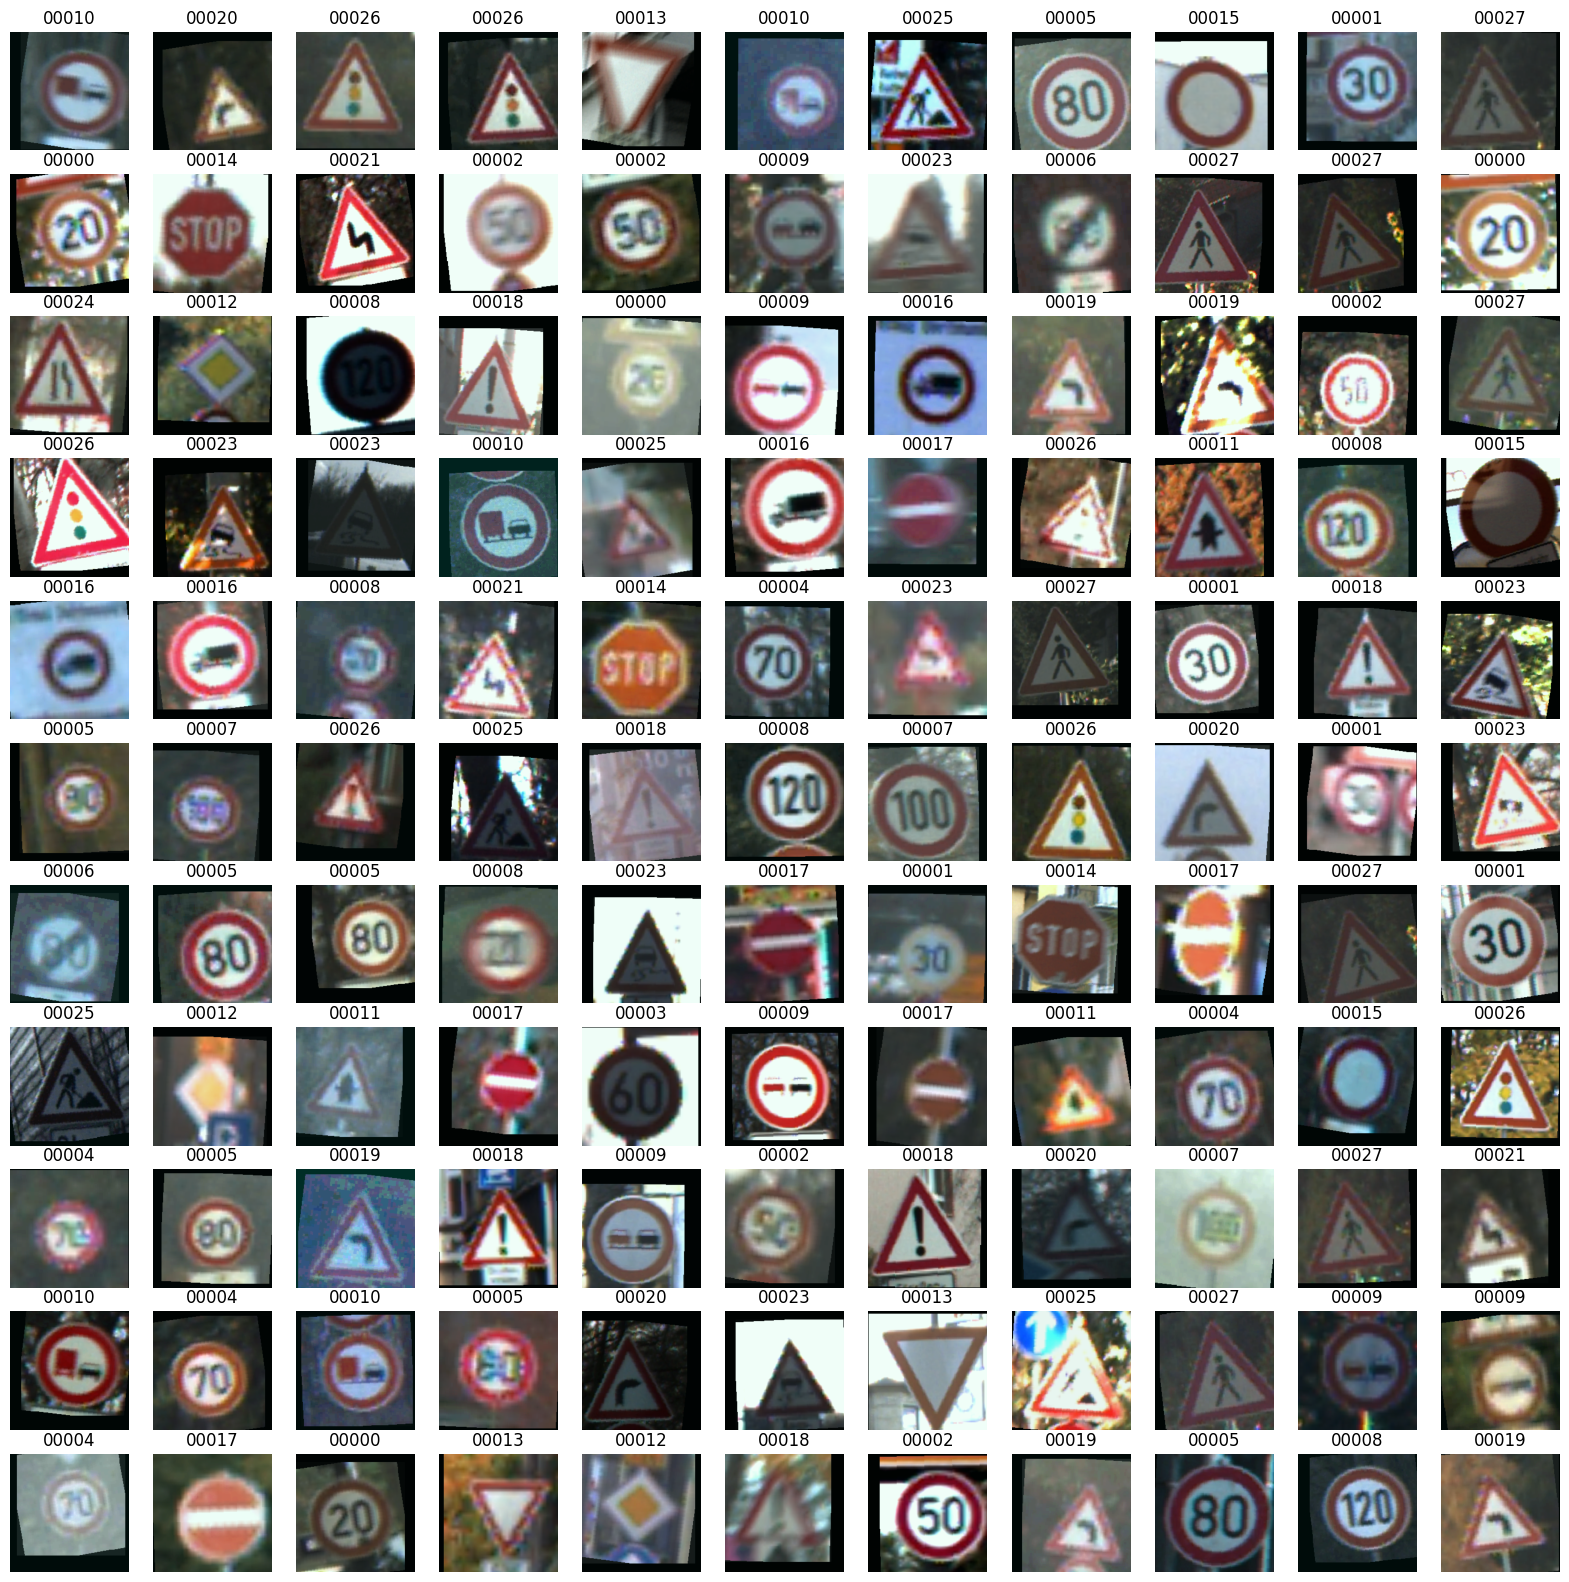

In [ ]:
classes = trainset.classes
plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model moved to: {device}")

Model moved to: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image

# 1. Định nghĩa loader an toàn để xử lý ảnh lỗi
def safe_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f)
            return img.convert('RGB')
    except Exception:
        return Image.new('RGB', (224, 224), (255, 255, 255))

trainset.loader = safe_loader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Khởi tạo lại Optimizer và Criterion cho model hiện tại
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# 3. Loader với num_workers=0 để tránh lỗi multiprocessing với safe_loader
train_loader = torch.utils.data.DataLoader(
    dataset=trainset, batch_size=32, sampler=sampler, num_workers=0, pin_memory=True
)

model.train()
running_loss, correct, total = 0, 0, 0

print(f"Bắt đầu training trên {device}...")

for i, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
        outputs = model(images)
        loss_val = criterion(outputs, labels)

    scaler.scale(loss_val).backward()
    scaler.step(optimizer)
    scaler.update()

    running_loss += loss_val.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    if (i + 1) % 100 == 0:
        print(f"Step [{i+1}/{len(train_loader)}], Loss: {loss_val.item():.4f}")

scheduler.step()
print(f"Kết thúc Epoch! Loss: {running_loss/len(train_loader):.4f}, Acc: {100*correct/total:.2f}%")

## Train Locality-iN-Locality

In [25]:
# ==============================
# Lưu lịch sử train
# ==============================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0.0

In [27]:
num_epochs = 12  # giam tu 40 -> 12, da co early stopping nen khong can qua nhieu


In [28]:
loss = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.cuda.amp.GradScaler()


/tmp/ipykernel_293/2515124125.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [37]:

import gc
import os
import torch
import torch.nn as nn
import torch.optim as optim

# Xác định thiết bị (GPU nếu có, không thì CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Hàm bổ trợ: evaluate và save_checkpoint
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def save_checkpoint(model, optimizer, scheduler, epoch, acc, best_acc, filename):
    state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'acc': acc,
        'best_acc': best_acc
    }
    torch.save(state, filename)

# 2. Giải phóng bộ nhớ
if 'model' in locals():
    del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# 3. Thiết lập tối ưu bộ nhớ
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# 4. Giảm batch_size xuống mức an toàn
batch_size = 16

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                            batch_size=batch_size,
                                            sampler=sampler,
                                            num_workers=2,
                                            pin_memory=torch.cuda.is_available())

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                           batch_size=batch_size,
                                           shuffle=False,
                                           num_workers=2,
                                           pin_memory=torch.cuda.is_available())

# Khởi tạo lại model LNL_Ti
from LNL import LNL_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)
model = model.to(device)

# Khởi tạo lại optimizer và scheduler
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
loss = nn.CrossEntropyLoss(label_smoothing=0.1)

best_acc = 0.0
patience = 5
epochs_no_improve = 0

try:
    for epoch in range(num_epochs):
        model.train()
        total_batch = len(trainset) // batch_size
        for i, (batch_images, batch_labels) in enumerate(train_loader):
            X = batch_images.to(device, non_blocking=True)
            Y = batch_labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=torch.cuda.is_available()):
                pre = model(X)
                cost = loss(pre, Y)

            if device.type == 'cuda':
                scaler.scale(cost).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                cost.backward()
                optimizer.step()

            if (i + 1) % 200 == 0:
                print(f'Epoch [{epoch + 1}/{num_epochs}], Iter [{i + 1}/{total_batch}], Loss: {cost.item():.6f}')

        scheduler.step()
        test_acc = evaluate(model, test_loader)
        print(f'Epoch [{epoch + 1}/{num_epochs}] - Test accuracy: {test_acc:.2f}%')

        if test_acc > best_acc:
            best_acc = test_acc
            epochs_no_improve = 0
            save_checkpoint(model, optimizer, scheduler, epoch+1, test_acc, best_acc, 'best_model.pth')
            print(f'  -> New best model saved ({best_acc:.2f}%)')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping sau {patience} epoch.')
                break
except RuntimeError as e:
    if "out of memory" in str(e) and device.type == 'cuda':
        print("Vẫn bị OOM. Vui lòng vào Runtime -> Restart Session và chạy lại từ đầu.")
        torch.cuda.empty_cache()
    else:
        raise e

print(f'Best test accuracy: {best_acc:.2f}%')

Using device: cuda
Epoch [1/12], Iter [200/2450], Loss: 3.134763
Epoch [1/12], Iter [400/2450], Loss: 2.727136
Epoch [1/12], Iter [600/2450], Loss: 1.787675
Epoch [1/12], Iter [800/2450], Loss: 1.048658
Epoch [1/12], Iter [1000/2450], Loss: 0.998574
Epoch [1/12], Iter [1200/2450], Loss: 0.851066
Epoch [1/12], Iter [1400/2450], Loss: 0.781547
Epoch [1/12], Iter [1600/2450], Loss: 0.796586
Epoch [1/12], Iter [1800/2450], Loss: 0.741016
Epoch [1/12], Iter [2000/2450], Loss: 0.740631
Epoch [1/12], Iter [2200/2450], Loss: 0.753779
Epoch [1/12], Iter [2400/2450], Loss: 0.723113
Epoch [1/12] - Test accuracy: 95.50%
  -> New best model saved (95.50%)
Epoch [2/12], Iter [200/2450], Loss: 0.746442
Epoch [2/12], Iter [400/2450], Loss: 0.744543
Epoch [2/12], Iter [600/2450], Loss: 0.734873
Epoch [2/12], Iter [800/2450], Loss: 0.716986
Epoch [2/12], Iter [1000/2450], Loss: 0.717209
Epoch [2/12], Iter [1200/2450], Loss: 0.812920
Epoch [2/12], Iter [1400/2450], Loss: 0.711803
Epoch [2/12], Iter [1600

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Kiểm tra xem biến epoch có tồn tại không, nếu không mặc định là 0
current_epoch = globals().get('epoch', 0)

# Lưu Checkpoint
save_dict = {
    'epoch': current_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict() if 'scheduler' in locals() else None
}

# Đảm bảo thư mục tồn tại trên Drive trước khi lưu
checkpoint_path = "/content/drive/MyDrive/LNL_Checkpoint/checkpoint.pth"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

torch.save(save_dict, checkpoint_path)
print(f"Đã lưu checkpoint (Epoch: {current_epoch}) vào Google Drive tại: {checkpoint_path}")

Đã lưu checkpoint (Epoch: 11) vào Google Drive tại: /content/drive/MyDrive/LNL_Checkpoint/checkpoint.pth


In [41]:
# import os
# files = os.listdir("./checkpoint")
# print("Files saved:")
# for f in files:
#     print(f)

In [42]:
from LNL import LNL_Ti as tiny_arch
import os
import torch
from collections import OrderedDict

# 1. Khởi tạo lại cấu trúc mô hình
model_eval = tiny_arch(pretrained=False)
model_eval.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

checkpoint_path = "best_model.pth"

# 2. Load trọng số
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

    # Kiểm tra xem checkpoint là dict chứa metadata hay chỉ là state_dict
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    # Loại bỏ prefix 'module.' (nếu có) để tương thích với model không dùng DataParallel
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v

    # Load với strict=False để bỏ qua các keys không khớp hoàn toàn nếu có sự khác biệt nhỏ về version/cấu trúc
    missing, unexpected = model_eval.load_state_dict(new_state_dict, strict=False)

    model_eval.eval()
    print(f"Successfully loaded model weights from: {checkpoint_path}")
    if missing:
        print(f"Note: Missing keys: {len(missing)}")
    if unexpected:
        print(f"Note: Unexpected keys: {len(unexpected)}")
else:
    print(f"Error: File {checkpoint_path} not found.")

Successfully loaded model weights from: best_model.pth


In [32]:
model.eval()

val_running_loss = 0

correct = 0

total = 0

In [65]:
model.eval()
val_running_loss = 0
correct = 0
total = 0

with torch.no_grad():
    # Sử dụng test_loader thay cho val_loader vì val_loader chưa được định nghĩa
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        loss = loss_fn(outputs, labels) if 'loss_fn' in globals() else criterion(outputs, labels)
        val_running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

epoch_val_loss = val_running_loss / len(test_loader)
epoch_val_acc = 100 * correct / total

val_losses.append(epoch_val_loss)
val_accs.append(epoch_val_acc)

print(f'Validation Loss: {epoch_val_loss:.4f}, Validation Acc: {epoch_val_acc:.2f}%')

Validation Loss: 3.3921, Validation Acc: 10.48%


In [63]:
checkpoint = {

    "epoch": epoch + 1,

    # Model

    "model_state_dict": model.state_dict(),

    # Optimizer

    "optimizer_state_dict": optimizer.state_dict(),

    # Scheduler

    "scheduler_state_dict": scheduler.state_dict(),

    # Loss

    "train_loss": train_losses,

    "val_loss": val_losses,


    # Accuracy

    "train_accuracy": train_accs,

    "val_accuracy": val_accs,

    # Best

    "best_accuracy": best_acc

}

torch.save(
    checkpoint,
    "checkpoint_full.pth"
)

## Test

In [46]:

import torch.nn.functional as F

# Xác định thiết bị tự động (GPU nếu có, không thì CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Sử dụng model_eval đã được nạp trọng số thành công ở ô trên
model_eval = model_eval.to(device)
model_eval.eval()

print(f"Using loaded LNL_Ti model for TTA evaluation on: {device}")

# Test-Time Augmentation
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(5),
        transforms.ToTensor(),
        transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
    ]),
]

# Đảm bảo đường dẫn chính xác (đã verify ở các bước trước)
base_test_path = '/content/data/GTSRB/test'
base_testset = torchvision.datasets.ImageFolder(root=base_test_path)
sample_labels = torch.tensor([label for _, label in base_testset.samples])
num_classes = len(base_testset.classes)

all_probs = torch.zeros(len(sample_labels), num_classes)

with torch.no_grad():
    for tform in tta_transforms:
        tta_testset = torchvision.datasets.ImageFolder(root=base_test_path, transform=tform)
        tta_loader = torch.utils.data.DataLoader(tta_testset, batch_size=batch_size,
                                                 shuffle=False, num_workers=2,
                                                 pin_memory=torch.cuda.is_available())
        probs_list = []
        for images, _ in tta_loader:
            images = images.to(device)
            outputs = model_eval(images)
            probs = F.softmax(outputs, dim=1)
            probs_list.append(probs.cpu())
        all_probs += torch.cat(probs_list, dim=0)

predicted = all_probs.argmax(dim=1)
correct = (predicted == sample_labels).sum().item()
total = len(sample_labels)

print('Standard accuracy (TTA): %.2f %%' % (100 * float(correct) / total))

Using loaded LNL_Ti model for TTA evaluation on: cuda
Standard accuracy (TTA): 99.47 %


In [47]:
# Verify class mapping consistency
print("Train class to idx sample (first 5):", list(trainset.class_to_idx.items())[:5])
print("Test class to idx sample (first 5):", list(base_testset.class_to_idx.items())[:5])

if trainset.class_to_idx == base_testset.class_to_idx:
    print("\n✅ Class mappings match!")
else:
    print("\n❌ Class mappings MISMATCH! This is why evaluation accuracy is low.")

Train class to idx sample (first 5): [('00000', 0), ('00001', 1), ('00002', 2), ('00003', 3), ('00004', 4)]
Test class to idx sample (first 5): [('00000', 0), ('00001', 1), ('00002', 2), ('00003', 3), ('00004', 4)]

✅ Class mappings match!


In [48]:
# Debug sample predictions vs labels
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_eval = model_eval.to(device)
model_eval.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model_eval(images)
    preds = outputs.argmax(dim=1)

    print(f"Device: {device}")
    print(f"Sample Labels: {labels[:10].tolist()}")
    print(f"Sample Preds:  {preds[:10].tolist()}")
    print(f"Matches:       {(preds == labels)[:10].tolist()}")

    # Check if labels are within valid range [0, 42]
    print(f"Label min/max: {labels.min().item()}/{labels.max().item()}")

Device: cuda
Sample Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample Preds:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Matches:       [True, True, True, True, True, True, True, True, True, True]
Label min/max: 0/0


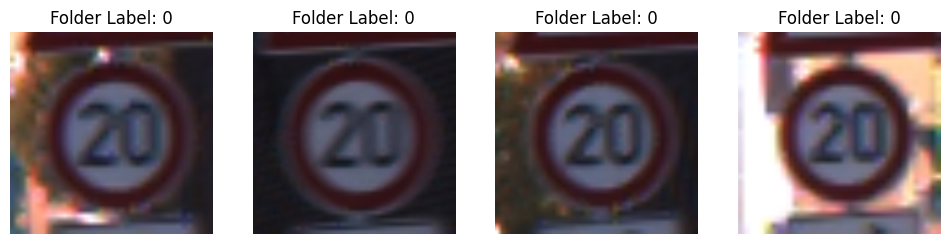

In [49]:
# Visualize some images from the test folder to see if labels match content
import matplotlib.pyplot as plt

def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

model_eval.eval()
images, labels = next(iter(test_loader))

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i].clone()
    img = denormalize(img, GTSRB_MEAN, GTSRB_STD)
    plt.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    plt.title(f"Folder Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

In [50]:
!pwd

/content/Locality-iN-Locality


## FGSM attack

In [ ]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

## PGD attack

In [ ]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

## train LNL-MoEx

In [ ]:
from LNL_MoEx import LNL_MoEx_S as small

model = small(pretrained=False)

# Dung dong in_features thay vi hardcode 192, vi LNL_MoEx_S co embed_dim khac LNL_MoEx_Ti
in_features = model.head.in_features
model.head = torch.nn.Linear(in_features=in_features, out_features=43, bias=True)


In [ ]:
# Xác định thiết bị (tự động chọn GPU nếu có, nếu không sẽ dùng CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Di chuyển mô hình vào thiết bị đã chọn
model = model.to(device)

print(f"Model is currently running on: {device}")

In [ ]:
import torch
import torchvision
from torchvision import transforms
import numpy as np

# 1. Định nghĩa lại transform (nếu chưa có)
GTSRB_MEAN = [0.3403, 0.3121, 0.3214]
GTSRB_STD = [0.2724, 0.2608, 0.2669]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])

# 2. Khởi tạo lại dataset từ đường dẫn đã verify
train_path = '/content/data/GTSRB/Final_Training/Images'
test_path = '/content/data/GTSRB/test'

trainset = torchvision.datasets.ImageFolder(root=train_path, transform=train_transform)
testset = torchvision.datasets.ImageFolder(root=test_path, transform=test_transform)

# 3. Tạo sampler để cân bằng dữ liệu
class_counts = np.bincount([label for _, label in trainset.samples])
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in trainset.samples]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# 4. Cấu hình DataLoader cho LNL_MoEx_S
# Gỉảm batch_size xuống 48 (hoặc thấp hơn nếu OOM trên T4)
batch_size = 48

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                            batch_size=batch_size,
                                            sampler=sampler,
                                            num_workers=2,
                                            pin_memory=torch.cuda.is_available())

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                           batch_size=batch_size,
                                           shuffle=False,
                                           num_workers=2,
                                           pin_memory=torch.cuda.is_available())

print(f"DataLoaders ready. Train size: {len(trainset)}, Test size: {len(testset)}")

In [51]:
num_epochs = 16  # giam tu 40 -> 16, da co early stopping
moex_lam = .9
moex_prob = .7


In [52]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Đảm bảo đang ở đúng thư mục chứa code
if os.path.exists('/content/Locality-iN-Locality'):
    os.chdir('/content/Locality-iN-Locality')
    print(f"Current directory: {os.getcwd()}")

try:
    from LNL_MoEx import LNL_MoEx_S as small_moex
except ImportError:
    print("LỖI: Vẫn không tìm thấy module LNL_MoEx. Vui lòng chạy lại ô lệnh Clone Git ở đầu notebook.")
    raise

# 2. Xác định thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Khởi tạo model LNL_MoEx_S
model = small_moex(pretrained=False)
in_features = model.head.in_features
model.head = nn.Linear(in_features=in_features, out_features=43, bias=True)
model = model.to(device)
print(f"Model initialized and moved to: {device}")

# 4. Thiết lập tham số và Scheduler (Sửa lỗi NameError)
# Lấy num_epochs từ global hoặc mặc định là 25
num_epochs = globals().get('num_epochs', 25)

loss = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Sử dụng GradScaler an toàn cho cả CPU và GPU
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

print(f"Setup complete with num_epochs={num_epochs}")

Current directory: /content/Locality-iN-Locality


/content/Locality-iN-Locality/models/tnt_moex.py:312: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/Locality-iN-Locality/models/tnt_moex.py:323: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/Locality-iN-Locality/models/tnt_moex.py:334: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


Model initialized and moved to: cuda
Setup complete with num_epochs=16


In [ ]:
import gc
import os
import torch
import numpy as np
from torch import optim
import torch.nn as nn

# 0. Thiết lập tham số mặc định
num_epochs = globals().get('num_epochs', 25)
moex_prob = globals().get('moex_prob', 0.7)
moex_lam = globals().get('moex_lam', 0.9)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# 1. Kiểm tra thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")
if device.type == 'cpu':
    print("CẢNH BÁO: Đang chạy trên CPU, tốc độ huấn luyện sẽ rất chậm. Hãy đổi sang GPU nếu có thể.")

# 2. Lấy dữ liệu trực tiếp từ globals()
train_dataset = globals().get('trainset')
test_dataset = globals().get('testset')

if train_dataset is None or test_dataset is None:
    print("LỖI: Không tìm thấy 'trainset' hoặc 'testset'.")
    print("Vui lòng cuộn lên và chạy lại ô lệnh gg7-xY0mXc5x để khởi tạo dữ liệu.")
else:
    # 3. Khởi tạo Sampler
    print("Đang chuẩn bị DataLoader...")
    class_counts = np.bincount([label for _, label in train_dataset.samples])
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[label] for _, label in train_dataset.samples]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # 4. Cấu hình DataLoader
    batch_size = 32
    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=torch.cuda.is_available())
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    # 5. Khởi tạo model LNL-MoEx-S
    from LNL_MoEx import LNL_MoEx_S as small_moex
    model = small_moex(pretrained=False)
    in_features = model.head.in_features
    model.head = nn.Linear(in_features=in_features, out_features=43, bias=True)
    model.to(device)

    # 6. Optimizer và Scaler
    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    print(f"Bắt đầu huấn luyện {num_epochs} epochs...")
    try:
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            for i, (input, target) in enumerate(train_loader):
                input, target = input.to(device), target.to(device)
                optimizer.zero_grad()

                with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=torch.cuda.is_available()):
                    prob = torch.rand(1).item()
                    if prob < moex_prob:
                        swap_index = torch.randperm(input.size(0), device=device)
                        output = model(input, swap_index=swap_index, moex_norm='pono', moex_layer='stem')
                        cost = loss_fn(output, target) * moex_lam + loss_fn(output, target[swap_index]) * (1. - moex_lam)
                    else:
                        output = model(input)
                        cost = loss_fn(output, target)

                if device.type == 'cuda':
                    scaler.scale(cost).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    cost.backward()
                    optimizer.step()

                epoch_loss += cost.item()
                if (i + 1) % 50 == 0:
                    print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {cost.item():.4f}')

            scheduler.step()
            print(f"Kết thúc Epoch {epoch+1}, Loss trung bình: {epoch_loss/len(train_loader):.4f}")
    except Exception as e:
        print(f"Lỗi: {e}")

Đang sử dụng thiết bị: cuda
Đang chuẩn bị DataLoader...
Bắt đầu huấn luyện 16 epochs...
Epoch [1/16], Step [50/1226], Loss: 3.5899
Epoch [1/16], Step [100/1226], Loss: 3.5394
Epoch [1/16], Step [150/1226], Loss: 3.5689
Epoch [1/16], Step [200/1226], Loss: 3.3489
Epoch [1/16], Step [250/1226], Loss: 3.0734
Epoch [1/16], Step [300/1226], Loss: 2.8798
Epoch [1/16], Step [350/1226], Loss: 1.9285
Epoch [1/16], Step [400/1226], Loss: 2.2395
Epoch [1/16], Step [450/1226], Loss: 1.8703
Epoch [1/16], Step [500/1226], Loss: 2.0078
Epoch [1/16], Step [550/1226], Loss: 1.9492
Epoch [1/16], Step [600/1226], Loss: 1.1142
Epoch [1/16], Step [650/1226], Loss: 1.6369
Epoch [1/16], Step [700/1226], Loss: 1.5799
Epoch [1/16], Step [750/1226], Loss: 0.8986
Epoch [1/16], Step [800/1226], Loss: 1.4559
Epoch [1/16], Step [850/1226], Loss: 1.3867
Epoch [1/16], Step [900/1226], Loss: 0.8099
Epoch [1/16], Step [950/1226], Loss: 0.8289
Epoch [1/16], Step [1000/1226], Loss: 1.3463
Epoch [1/16], Step [1050/1226], 

In [ ]:
import os
import zipfile

# 1. Kiểm tra các file zip đã tải
zip_files = ['data/GTSRB_Final_Training_Images.zip', 'data/GTSRB_Final_Test_Images.zip']
for z in zip_files:
    if os.path.exists(z):
        print(f"Đang giải nén {z}...")
        with zipfile.ZipFile(z, 'r') as zip_ref:
            zip_ref.extractall('data/')
    else:
        print(f"CẢNH BÁO: Không tìm thấy file {z}. Hãy chạy lại ô tải dữ liệu (curl).")

# 2. Tìm lại đường dẫn thực tế sau khi giải nén
def find_path(name):
    for root, dirs, files in os.walk('/content/data'):
        if name in dirs:
            # Trả về root (thư mục cha chứa các folder lớp) thay vì đường dẫn trực tiếp tới class folder
            return root
    return None

train_path = find_path('00000')

if train_path:
    print(f"Thành công! Đã tìm thấy dữ liệu tại: {train_path}")
    # Cập nhật biến để các ô sau có thể sử dụng
    correct_train_path = train_path
    from torchvision.datasets import ImageFolder
    # Đảm bảo train_transform đã được định nghĩa ở các cell trước
    dataset = ImageFolder(root=train_path, transform=train_transform)
    print(f"Số lượng ảnh loaded: {len(dataset)}")
else:
    print("Vẫn không tìm thấy thư mục '00000'. Vui lòng kiểm tra dung lượng ổ đĩa hoặc link tải.")
    !ls -R /content/data

In [57]:
import os
import torchvision
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder

def find_dataset_root(search_path, hint='00000'):
    for root, dirs, files in os.walk(search_path):
        if hint in dirs:
            class_path = os.path.join(root, hint)
            # Kiểm tra xem có file ảnh nào không
            if any(f.lower().endswith(('.ppm', '.jpg', '.png')) for f in os.listdir(class_path)):
                return root
    return None

# Tìm kiếm vị trí thực tế của train và test
# Dữ liệu train thường nằm trong Final_Training/Images hoặc tương đương
correct_train_path = find_dataset_root('/content', hint='00000')
# Dữ liệu test đã được tổ chức lại vào thư mục 'test' ở bước trước
# Nếu /content/data/GTSRB/test không có, ta tìm kiếm thư mục 'test' chứa class folders
correct_test_path = find_dataset_root('/content/data/GTSRB', hint='00000')

if not correct_train_path:
    raise FileNotFoundError("Không tìm thấy thư mục huấn luyện. Vui lòng chạy lại các bước tải và giải nén dữ liệu.")
if not correct_test_path:
    # Thử tìm kiếm rộng hơn cho test nếu hint đầu tiên thất bại
    correct_test_path = find_dataset_root('/content', hint='00000')

GTSRB_MEAN = [0.3403, 0.3121, 0.3214]
GTSRB_STD = [0.2724, 0.2608, 0.2669]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])

# Tải dataset và gán vào các biến toàn cục mà cell S2341jKpOm28 yêu cầu
trainset = ImageFolder(root=correct_train_path, transform=train_transform)
testset = ImageFolder(root=correct_test_path, transform=test_transform)

print(f"Thành công!")
print(f"Đường dẫn Train: {correct_train_path} ({len(trainset)} ảnh)")
print(f"Đường dẫn Test: {correct_test_path} ({len(testset)} ảnh)")

Thành công!
Đường dẫn Train: /content/data/GTSRB/Final_Training/Images (39209 ảnh)
Đường dẫn Test: /content/data/GTSRB/Final_Training/Images (39209 ảnh)


## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [ ]:
%cd /content
!rm -rf Locality-iN-Locality

In [ ]:
!git clone --recursive https://github.com/Omid-Nejati/Locality-iN-Locality.git

In [ ]:
!ls /content/Locality-iN-Locality

In [ ]:
!ls /content/Locality-iN-Locality/models

In [ ]:
!pip install timm ptflops

In [ ]:
import sys
import os

repo_path="/content/Locality-iN-Locality"

sys.path.insert(
    0,
    repo_path
)

from LNL import LNL_Ti

print("Load LNL_Ti thành công")

In [ ]:
import torch


model = LNL_Ti(
    pretrained=False
)


model.head = torch.nn.Linear(
    192,
    43
)


model.eval()


print(model)

In [ ]:
checkpoint = torch.load(
    "/content/checkpoint.pth",
    map_location="cpu"
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)


print("Checkpoint load OK")

In [ ]:
from ptflops import get_model_complexity_info


macs, params = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=True,
    print_per_layer_stat=False
)


print("============================")
print("FLOPs:", macs)
print("Params:", params)
print("============================")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls /content//drive/MyDrive/LNL_Checkpoint/

In [ ]:
!git clone -q https://github.com/nayeongchul/Locality-iN-Locality.git
sys.path.insert(0, '/content/Locality-iN-Locality')

In [ ]:
from LNL import LNL_Ti

In [ ]:
CKPT = '/content/drive/MyDrive/LNL_Checkpoint/checkpoint.pth'
TEST_DIR = '/content/data/GTSRB/test'

In [56]:
import sys, torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from LNL import LNL_Ti

# ===== ĐƯỜNG DẪN =====
CKPT = '/content/drive/MyDrive/LNL_Checkpoint/checkpoint.pth'
TEST_DIR = '/content/data/GTSRB/test'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Transform giống lúc train
tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.3403,0.3121,0.3214],
                         [0.2724,0.2608,0.2669])
])

test_loader = DataLoader(
    datasets.ImageFolder(TEST_DIR, transform=tf),
    batch_size=64, shuffle=False, num_workers=2
)

# Model
model = LNL_Ti(pretrained=False)
model.head = torch.nn.Linear(192, 43)

ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()

# Test clean accuracy
correct = total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

print(f'Accuracy: {100*correct/total:.2f}% ({correct}/{total})')

Accuracy: 99.45% (12561/12630)
